![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

Primeras filas del dataset:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3              36.7             19.3              193.0       3450.0  FEMALE
4              39.3             20.6              190.0       3650.0    MALE

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 

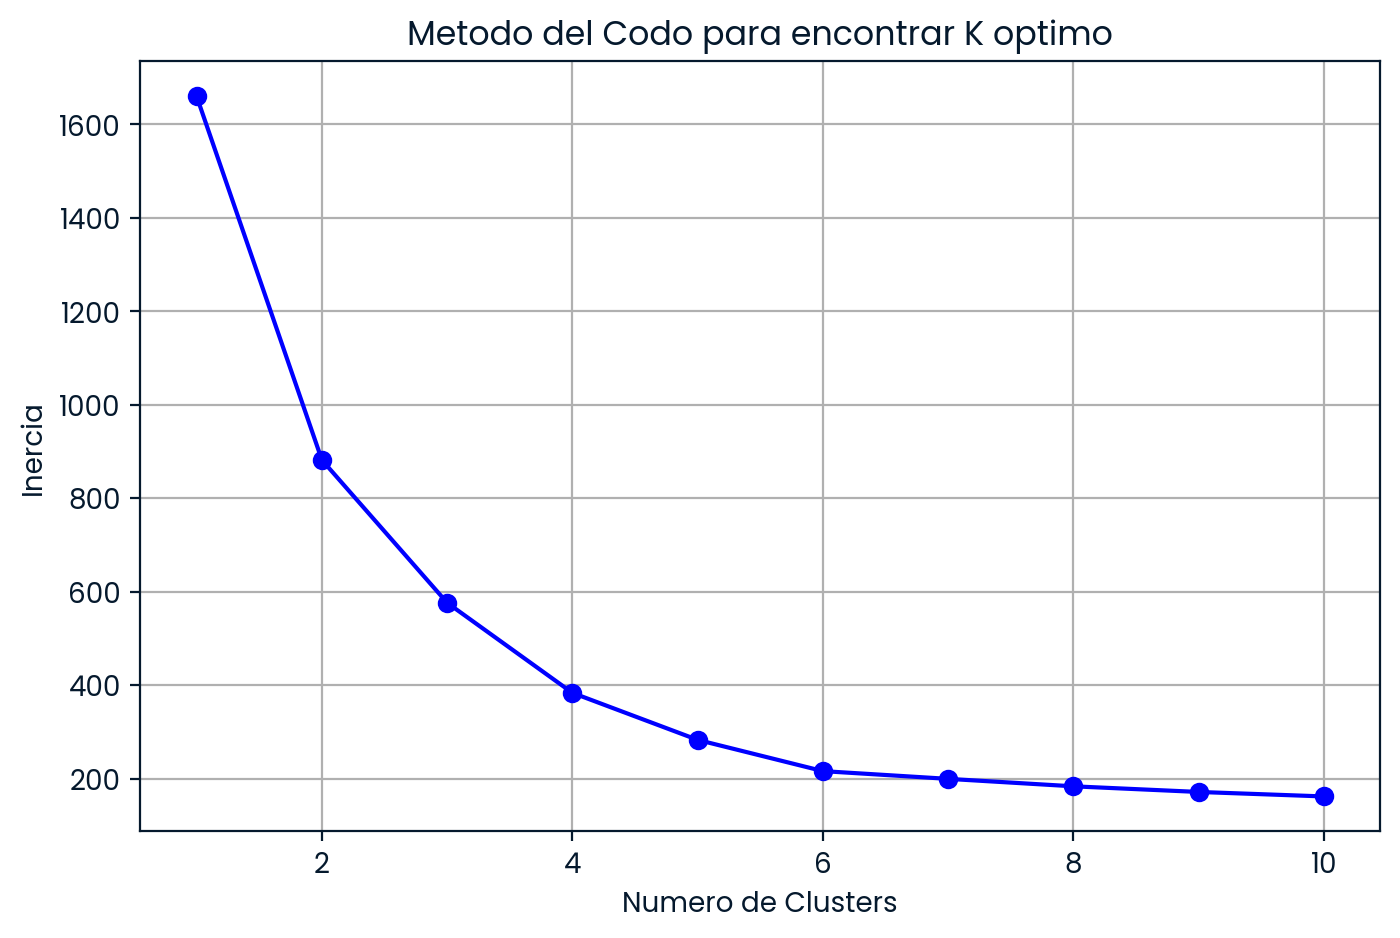


Usando 3 clusters para el analisis

Estadisticas por cluster (stat_penguins):
         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
cluster                                                                   
0               43.878302        19.111321         194.764151  4006.603774
1               47.568067        14.996639         217.235294  5092.436975
2               40.217757        17.611215         189.046729  3419.158879


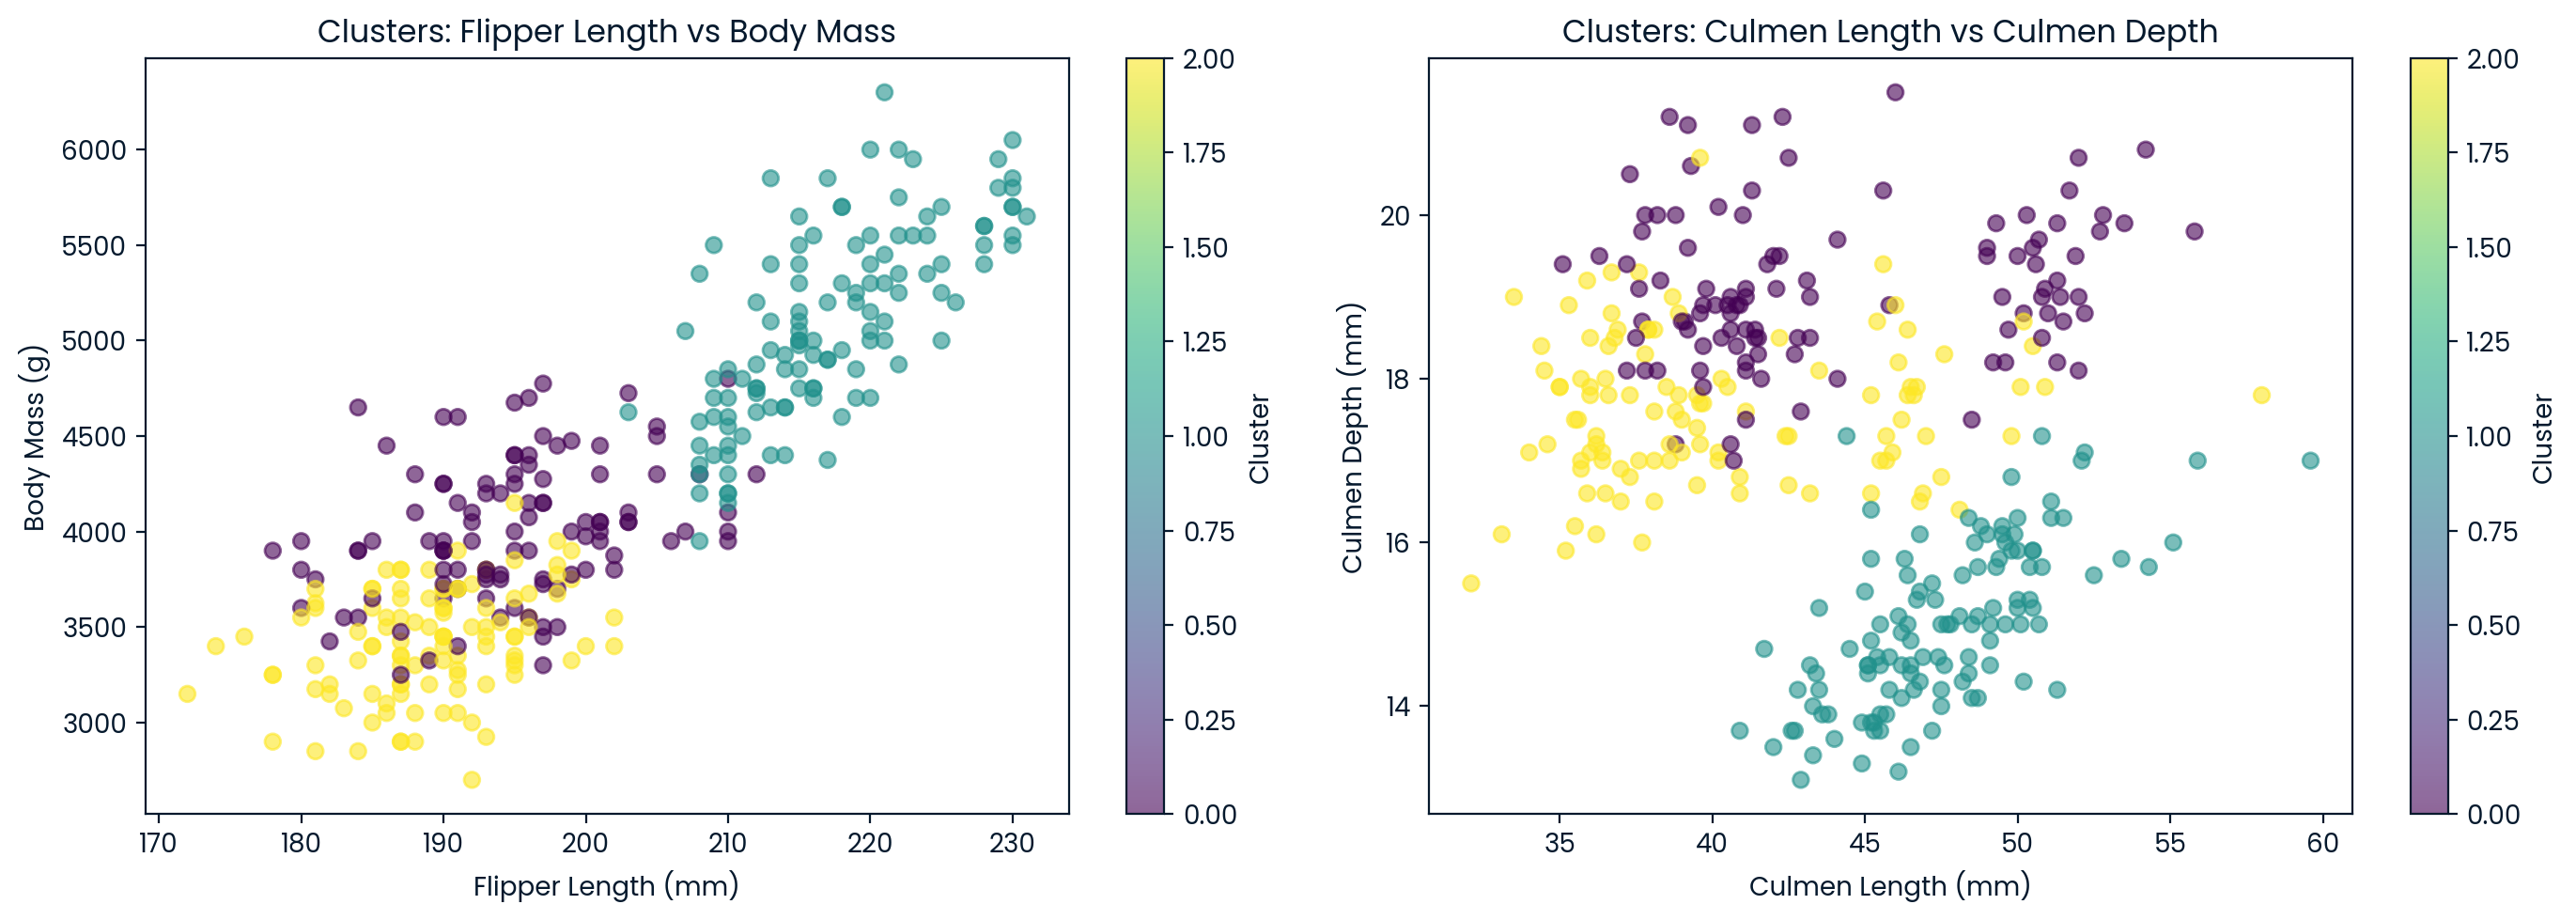


Distribucion de pinguinos por cluster:
0    106
1    119
2    107
Name: cluster, dtype: int64

Resumen de diferencias entre clusters:

Cluster 0:
  Promedio body mass: 4006.6 g
  Promedio flipper length: 194.8 mm
  Cantidad de individuos: 106

Cluster 1:
  Promedio body mass: 5092.4 g
  Promedio flipper length: 217.2 mm
  Cantidad de individuos: 119

Cluster 2:
  Promedio body mass: 3419.2 g
  Promedio flipper length: 189.0 mm
  Cantidad de individuos: 107


In [1]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
print("Primeras filas del dataset:")
print(penguins_df.head())

# vamos a ver que tiene el dataset
print("\nInformacion del dataset:")
print(penguins_df.info())

print("\nEstadisticas basicas:")
print(penguins_df.describe())

# revisar si hay valores nulos
print("\nValores faltantes por columna:")
print(penguins_df.isnull().sum())

# limpieza de datos - quitar filas con valores faltantes
# no se me ocurre otra forma jaja
penguins_clean = penguins_df.dropna()
print(f"\nFilas antes: {len(penguins_df)}, Filas despues: {len(penguins_clean)}")

# la columna sex es texto, tengo que convertirla a numeros
# voy a usar 0 para MALE y 1 para FEMALE
penguins_clean['sex_numeric'] = penguins_clean['sex'].map({'MALE': 0, 'FEMALE': 1})

# ahora selecciono solo las columnas numericas para el clustering
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 
                   'body_mass_g', 'sex_numeric']
penguins_numeric = penguins_clean[numeric_columns]

# normalizar los datos porque tienen escalas diferentes
# aprendi que esto es importante para k-means
scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_numeric)

# metodo del codo para encontrar el numero optimo de clusters
# probando de 1 a 10 clusters
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(penguins_scaled)
    inertias.append(kmeans_temp.inertia_)

# graficar el metodo del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Numero de Clusters')
plt.ylabel('Inercia')
plt.title('Metodo del Codo para encontrar K optimo')
plt.grid(True)
plt.show()

# segun la grafica, parece que 3 clusters es bueno (que tiene sentido porque hay 3 especies!)
# voy a usar k=3
k_optimo = 3
print(f"\nUsando {k_optimo} clusters para el analisis")

# aplicar kmeans con 3 clusters
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(penguins_scaled)

# agregar los clusters al dataframe original
penguins_clean['cluster'] = clusters

# crear el dataframe stat_penguins con las medias por cluster
# solo con las columnas numericas originales (sin sex_numeric)
original_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
stat_penguins = penguins_clean.groupby('cluster')[original_columns].mean()

print("\nEstadisticas por cluster (stat_penguins):")
print(stat_penguins)

# hacer una visualizacion para ver como quedaron los clusters
# voy a graficar flipper_length vs body_mass que parecen importantes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# grafico 1: flipper length vs body mass
scatter1 = ax[0].scatter(penguins_clean['flipper_length_mm'], 
                         penguins_clean['body_mass_g'],
                         c=penguins_clean['cluster'], 
                         cmap='viridis', 
                         alpha=0.6)
ax[0].set_xlabel('Flipper Length (mm)')
ax[0].set_ylabel('Body Mass (g)')
ax[0].set_title('Clusters: Flipper Length vs Body Mass')
plt.colorbar(scatter1, ax=ax[0], label='Cluster')

# grafico 2: culmen length vs culmen depth
scatter2 = ax[1].scatter(penguins_clean['culmen_length_mm'], 
                         penguins_clean['culmen_depth_mm'],
                         c=penguins_clean['cluster'], 
                         cmap='viridis', 
                         alpha=0.6)
ax[1].set_xlabel('Culmen Length (mm)')
ax[1].set_ylabel('Culmen Depth (mm)')
ax[1].set_title('Clusters: Culmen Length vs Culmen Depth')
plt.colorbar(scatter2, ax=ax[1], label='Cluster')

plt.tight_layout()
plt.show()

# ver cuantos pinguinos hay en cada cluster
print("\nDistribucion de pinguinos por cluster:")
print(penguins_clean['cluster'].value_counts().sort_index())

# mostrar algunas diferencias entre clusters
print("\nResumen de diferencias entre clusters:")
for i in range(k_optimo):
    print(f"\nCluster {i}:")
    print(f"  Promedio body mass: {stat_penguins.loc[i, 'body_mass_g']:.1f} g")
    print(f"  Promedio flipper length: {stat_penguins.loc[i, 'flipper_length_mm']:.1f} mm")
    print(f"  Cantidad de individuos: {len(penguins_clean[penguins_clean['cluster'] == i])}")